BrainTumorDetection/

│

├── dataset/

│     ├── Training/

│     ├── Testing/

│

├── notebooks/

│

├── models/

│

├── app.py

├── train.py

├── predict.py

├── preprocess.py

├── requirements.txt

├── README.md

└── images/

In [ ]:
# Install Libraries
!pip install tensorflow
!pip install opencv-python
!pip install matplotlib
!pip install scikit-learn
!pip install pillow
!pip install streamlit

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.4/10.4 MB 85.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.4/11.4 MB 94.1 MB/s eta 0:00:00


**Import Libraries**

In [ ]:
import tensorflow as tf

from tensorflow.keras.preprocessing.image import ImageDataGenerator

from tensorflow.keras.models import Sequential

from tensorflow.keras.layers import Conv2D

from tensorflow.keras.layers import MaxPooling2D

from tensorflow.keras.layers import Flatten

from tensorflow.keras.layers import Dense

from tensorflow.keras.layers import Dropout

import matplotlib.pyplot as plt

import numpy as np

**Data Preprocessing**

In [ ]:
# Image Augmentation
train_datagen = ImageDataGenerator(

    rescale=1./255,

    rotation_range=20,

    zoom_range=0.2,

    horizontal_flip=True,

    validation_split=0.2

)


**Mount the Google Drive**

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


**Define Paths**

In [ ]:
train_path = "/content/drive/MyDrive/Brain_Tumor/Training"
test_path = "/content/drive/MyDrive/Brain_Tumor/Testing"

**Create ImageDataGenerator**

In [ ]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator

train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=20,
    zoom_range=0.2,
    horizontal_flip=True,
    validation_split=0.2
)

**Training Generator**

In [ ]:
train_generator = train_datagen.flow_from_directory(
    train_path,
    target_size=(224, 224),
    batch_size=32,
    class_mode="categorical",
    subset="training"
)

Found 4480 images belonging to 4 classes.


**Validation Generator**

In [ ]:
validation_generator = train_datagen.flow_from_directory(
    train_path,
    target_size=(224, 224),
    batch_size=32,
    class_mode="categorical",
    subset="validation"
)

Found 1120 images belonging to 4 classes.


**Test Generator (used after training)**

In [ ]:
test_datagen = ImageDataGenerator(rescale=1./255)

test_generator = test_datagen.flow_from_directory(
    test_path,
    target_size=(224, 224),
    batch_size=32,
    class_mode="categorical",
    shuffle=False
)

Found 1600 images belonging to 4 classes.


In [ ]:
import os

print(os.listdir("/content/drive/MyDrive/Brain_Tumor"))
print(os.listdir(train_path))

['Training', 'AI_Medical_Assistant_Project_Synopsis.pdf', 'Testing']
['pituitary', 'notumor', 'glioma', 'meningioma']


**Load Dataset**

In [ ]:
train_generator = train_datagen.flow_from_directory(

    train_path,

    target_size=(224,224),

    batch_size=32,

    class_mode="categorical",

    subset="training"

)

Found 4480 images belonging to 4 classes.


In [ ]:
validation_generator = train_datagen.flow_from_directory(

    test_path,

    target_size=(224,224),

    batch_size=32,

    class_mode="categorical",

    subset="validation"

)

Found 320 images belonging to 4 classes.


**Check Classes**

In [ ]:
print(train_generator.class_indices)

{'glioma': 0, 'meningioma': 1, 'notumor': 2, 'pituitary': 3}


**CNN Model**

In [ ]:
# Build CNN
model = Sequential()

model.add(

Conv2D(

32,

(3,3),

activation="relu",

input_shape=(224,224,3)

)

)

model.add(MaxPooling2D(pool_size=(2,2)))

model.add(

Conv2D(

64,

(3,3),

activation="relu"

)

)

model.add(MaxPooling2D(pool_size=(2,2)))

model.add(

Conv2D(

128,

(3,3),

activation="relu"

)

)

model.add(MaxPooling2D(pool_size=(2,2)))

model.add(Flatten())

model.add(Dense(128,activation="relu"))

model.add(Dropout(0.5))

model.add(Dense(4,activation="softmax"))

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


**Model Summary**

In [ ]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 222, 222, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 111, 111, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 109, 109, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 54, 54, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 52, 52, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 26, 26, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 86528)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │    11,075,712 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 4)              │           516 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 11,169,476 (42.61 MB)

 Trainable params: 11,169,476 (42.61 MB)

 Non-trainable params: 0 (0.00 B)

**Model Compilation**

In [ ]:
# Compile
model.compile(

optimizer="adam",

loss="categorical_crossentropy",

metrics=["accuracy"]

)

**Model Training**

In [ ]:
# Train
history = model.fit(

train_generator,

epochs=10,

validation_data=validation_generator

)

Epoch 1/5
140/140 ━━━━━━━━━━━━━━━━━━━━ 345s 2s/step - accuracy: 0.7145 - loss: 0.7118 - val_accuracy: 0.6281 - val_loss: 1.0740
Epoch 2/5
140/140 ━━━━━━━━━━━━━━━━━━━━ 349s 2s/step - accuracy: 0.7571 - loss: 0.6202 - val_accuracy: 0.7031 - val_loss: 0.9843
Epoch 3/5
140/140 ━━━━━━━━━━━━━━━━━━━━ 365s 3s/step - accuracy: 0.7855 - loss: 0.5644 - val_accuracy: 0.7188 - val_loss: 0.8317
Epoch 4/5
140/140 ━━━━━━━━━━━━━━━━━━━━ 367s 3s/step - accuracy: 0.8036 - loss: 0.5283 - val_accuracy: 0.6781 - val_loss: 0.8336
Epoch 5/5
140/140 ━━━━━━━━━━━━━━━━━━━━ 358s 3s/step - accuracy: 0.8078 - loss: 0.4804 - val_accuracy: 0.6844 - val_loss: 0.8150


**Performance**

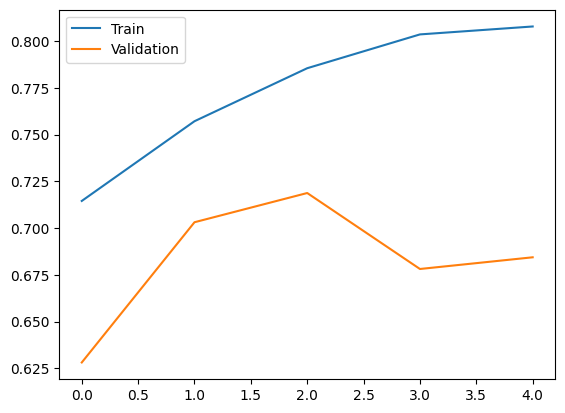

In [ ]:
# Plot Accuracy
plt.plot(history.history["accuracy"])

plt.plot(history.history["val_accuracy"])

plt.legend(["Train","Validation"])

plt.show()

**Plot Loss**

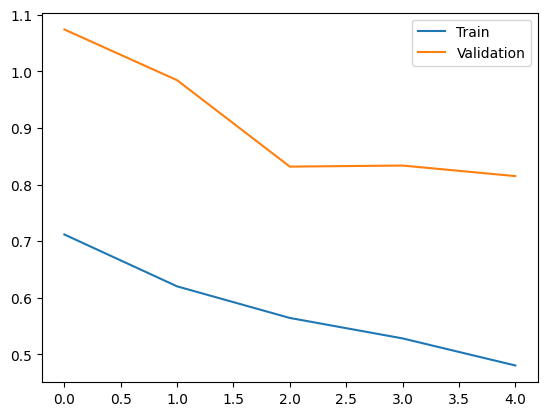

In [ ]:
plt.plot(history.history["loss"])

plt.plot(history.history["val_loss"])

plt.legend(["Train","Validation"])

plt.show()

**Evaluate**

In [ ]:
loss,accuracy=model.evaluate(validation_generator)

print(accuracy)

10/10 ━━━━━━━━━━━━━━━━━━━━ 10s 945ms/step - accuracy: 0.7125 - loss: 0.7914
0.7124999761581421


**Save Model**

In [ ]:
model.save("brain_tumor_model.keras")

**Prediction**

In [ ]:
# Load Model
from tensorflow.keras.models import load_model

model=load_model("brain_tumor_model.keras")

**Read Image**

In [ ]:
from tensorflow.keras.preprocessing import image

img=image.load_img(

"/content/drive/MyDrive/Brain_Tumor/Training/Multiple-Views-Of-Brain-MRI-Results-1024x499.webp",

target_size=(224,224)

)

img=image.img_to_array(img)

img=img/255

img=np.expand_dims(img,axis=0)

**Prediction**

In [ ]:
prediction=model.predict(img)

classes=["Glioma",

"Meningioma",

"No Tumor",

"Pituitary"]

print(classes[np.argmax(prediction)])

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 107ms/step
No Tumor


**Upload MRI**

In [ ]:
import streamlit as st

uploaded_file = st.file_uploader(

"Upload MRI",

type=["jpg","png","jpeg"]

)

2026-07-22 17:09:18.552 WARNING streamlit.runtime.scriptrunner_utils.script_run_context: Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-07-22 17:09:18.554 WARNING streamlit.runtime.scriptrunner_utils.script_run_context: Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-07-22 17:09:18.566 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-07-22 17:09:18.993 
  command:

    streamlit run /usr/local/lib/python3.12/dist-packages/colab_kernel_launcher.py [ARGUMENTS]
2026-07-22 17:09:18.994 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-07-22 17:09:18.995 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.


**Display Image**

**Predict**

In [ ]:
if st.button("Predict"):

    prediction=model.predict(img)

    st.success(

    classes[np.argmax(prediction)]

    )

2026-07-22 17:10:11.949 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-07-22 17:10:11.952 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-07-22 17:10:11.954 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-07-22 17:10:11.955 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-07-22 17:10:11.956 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.


**Confidence**

In [ ]:
confidence=np.max(prediction)*100

st.write(

f"Confidence : {confidence:.2f}%"

)

2026-07-22 17:10:15.712 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-07-22 17:10:15.715 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-07-22 17:10:15.715 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
